In [2]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import time
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
DATA_ROOT='../data/the-oxfordiiit-pet-dataset'
BATCH_SIZE=16
NUM_WORKERS=4
EPOCHS=500
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=480
N_CLASSES=2
IGNORE_INDEX=255
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

OUT_DIR='runs'
BEST_PATH='./runs/best_m.pt'

In [4]:
def make_transform(train):

    def _tfm(img, mask):
        # 1. 이미지와 마스크 증강 (PIL -> PIL)
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)

        if train and random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        mask_np = np.array(mask)
        mask_np[mask_np == 2] = 0
        mask_np[mask_np == 3] = 0

        mask = torch.as_tensor(mask_np, dtype=torch.long)
        
        return img, mask
    return _tfm

class PetTrimapDataset(Dataset):
    def __init__(self, root, file_list, tf=None):
        self.root = Path(root)
        self.files = file_list
        self.tf = tf
        self.img_dir = self.root / 'images'
        self.seg_dir = self.root / 'annotations' / 'trimaps'

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        img_path = self.img_dir / filename
        mask_path = self.seg_dir / Path(filename).with_suffix('.png')

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        if self.tf:
            img, mask = self.tf(img, mask)
        
        return img, mask

def get_loaders(root, batch_size, split_ratio=0.8, random_seed=42, num_workers=2):
    image_dir = Path(root) / 'images'
    all_files = [f.name for f in image_dir.glob('*.jpg')]

    random.seed(random_seed)
    random.shuffle(all_files)
    
    split_index = int(len(all_files) * split_ratio)
    tr_files = all_files[:split_index]
    val_files = all_files[split_index:]

    print(f"총 {len(all_files)}개 이미지 발견")
    print(f"학습 데이터: {len(tr_files)}개, 검증 데이터: {len(val_files)}개")

    tr_ds = PetTrimapDataset(root, tr_files, tf=make_transform(train=True))
    val_ds = PetTrimapDataset(root, val_files, tf=make_transform(train=False))
    
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return tr_ds, val_ds, tr_loader, val_loader

tr_ds, val_ds, tr_loader, val_loader = get_loaders(
    root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS 
)

총 7390개 이미지 발견
학습 데이터: 5912개, 검증 데이터: 1478개


In [5]:
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds,indices=None,n=6,alpha=0.5,ignore_idx=255):
    if indices is None:
        import random 
        n=min(n,len(ds))
        indices=random.sample(range(len(ds)),k=n)
    else:
        n=len(indices)
    r,c=n,3
    plt.figure(figsize=(c*4,r*3.5))

    for i, idx in enumerate(indices):
        sample=ds[idx]
        if len(sample)==3:
            img,mask,id_=sample
        else:
            img,mask=sample   
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb=_colorize_binary(mask_np,ignore_idx)
        over=overlay_mask(img_np,mask_rgb,alpha)

        base=i *3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')
        
        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
import torch
import torch.nn as nn
import timm

# DoubleConv 블록은 그대로 사용합니다. (이전 제안드렸던 BatchNorm 포함 버전)
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv_block(x)

# 디코더를 위한 UP 블록을 좀 더 유연하게 수정합니다.
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # 업샘플링 후 채널 수를 절반으로 줄입니다.
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        # Skip connection과 합쳐진 후의 채널 수를 입력으로 받는 DoubleConv
        # (in_channels // 2) + skip_channels
        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x, skip_connection):
        x = self.up(x)
        x = torch.cat([skip_connection, x], dim=1)
        return self.conv(x)

# 최종 모델: U-Net with EfficientNet Encoder
class UNetWithEfficientNetEncoder(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()

        # 1. 사전 훈련된 EfficientNet-B5를 인코더로 로드합니다.
        # features_only=True로 설정하면, 각 스테이지의 특징 맵을 리스트 형태로 출력해줍니다.
        self.encoder = timm.create_model(
            'efficientnet_b5',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4) # 5개의 특징 맵을 모두 사용
        )

        # 2. EfficientNet 각 스테이지의 출력 채널 수를 확인합니다.
        # 예: [24, 40, 64, 176, 512]
        encoder_channels = [info['num_chs'] for info in self.encoder.feature_info]
        
        # 3. 디코더 블록을 정의합니다.
        # 인코더 채널 수에 맞춰 디코더의 입력/출력 채널을 설정합니다.
        # 출력 채널 수는 임의로 설정 가능합니다 (예: 256, 128, 64, 32)
        self.up1 = DecoderBlock(encoder_channels[4], encoder_channels[3], 256)
        self.up2 = DecoderBlock(256, encoder_channels[2], 128)
        self.up3 = DecoderBlock(128, encoder_channels[1], 64)
        self.up4 = DecoderBlock(64, encoder_channels[0], 32)

        # 4. 최종 출력 레이어를 정의합니다.
        self.outc = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, image_input):
        # 인코더를 통과시켜 skip connection으로 사용할 특징 맵들을 얻습니다.
        # features는 리스트 형태이며, 얕은 층부터 깊은 층 순서입니다.
        features = self.encoder(image_input)
        
        # features 리스트의 순서: [x1, x2, x3, x4, x5]
        # x1: 24채널, H/2
        # x2: 40채널, H/4
        # x3: 64채널, H/8
        # x4: 176채널, H/16
        # x5: 512채널, H/32 (가장 깊은 층, bottleneck)
        x1, x2, x3, x4, x5 = features

        # 디코더를 통과시키며 skip connection을 연결합니다.
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        
        return F.interpolate(logits, size=image_input.shape[2:], mode='bilinear', align_corners=False)

In [7]:
os.makedirs(os.path.dirname(BEST_PATH),exist_ok=True)

BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over
    
@torch.no_grad()
def show_samples(model, loader, batches=1, alpha=0.5, ignore_idx=255, max_rows=None):
    model.eval()
    it = iter(loader)
    for _ in range(batches):
        try:
            batch = next(it)
        except:
            break
        
        if len(batch) == 3:
            x, y, _ = batch
        else:
            x, y = batch
        
        imgs, gts = x.to(DEVICE), y.to(DEVICE)

        logits = model(imgs)
        preds = torch.argmax(logits, dim=1)

        B = imgs.size(0)
        if max_rows is not None:
            B = min(max_rows, B)
        
        r, c = B, 4
        plt.figure(figsize=(c * 4, r * 3.5))
        for i in range(B):
            img_np = _denorm(imgs[i])
            gt_np = gts[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            
            gt_rgb = _colorize_binary(gt_np)
            pr_rgb = _colorize_binary(pr_np)
            over = overlay_mask(img_np, pr_rgb, alpha)

            base = i * 4
            plt.subplot(r, c, base + 1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')
        
            plt.subplot(r, c, base + 2)
            plt.imshow(gt_rgb)
            plt.title('t_mask')
            plt.axis('off')

            plt.subplot(r, c, base + 3)
            plt.imshow(pr_rgb)
            plt.title('p_mask')
            plt.axis('off')
        
            plt.subplot(r, c, base + 4)
            plt.imshow(over)
            plt.title('p_overlay')
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()

In [8]:
def fast_hist(pred,label,n_class=21,ignore_idx=255):
    mask=label!=ignore_idx
    pred=pred[mask]
    label=label[mask]
    hist=np.bincount(n_class*label.astype(int)+pred.astype(int), minlength=n_class**2).reshape(n_class,n_class).astype(np.float64)
    return hist
    
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [9]:
def train(model,criterion,opt,scaler,loader,device,epoch,scheduler):
    model.train()
    run=0.0
    t0=time.time()
    for x,y in tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)

        opt.zero_grad(set_to_none=True)
        # mac
        # with torch.amp.autocast('mps', enabled=torch.backends.mps.is_available()):
        # cuda
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = criterion(logits,masks.long())
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()*imgs.size(0)
        
    avg_loss = run/len(loader.dataset)
    print(f"[Epoch{epoch}] tr_loss:{avg_loss:.3f} | lr:{scheduler.get_last_lr()[0]:.6f} | t:{time.time()-t0:.3f}")
    return avg_loss
    
@torch.no_grad()
def evaluate(model, loader, device, criterion):
    model.eval()
    running_loss = 0.0
    hist = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float64)

    for imgs, masks in tqdm(loader, desc="[Eval]"):
        imgs, masks = imgs.to(device), masks.to(device)

        logits = model(imgs)
        loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        hist += fast_hist(preds.cpu().numpy().flatten(), masks.cpu().numpy().flatten(), N_CLASSES)

    avg_loss = running_loss / len(loader.dataset)
    miou, _ = miou_from_hist(hist)

    return avg_loss, miou

In [10]:
m=UNetWithEfficientNetEncoder(N_CLASSES).to(DEVICE)
criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
class_weights = torch.tensor([1.0, 5.0], device=DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)
# cuda
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
# mac
# scaler = torch.amp.GradScaler(enabled=torch.backends.mps.is_available())

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


100%|██████████| 370/370 [01:38<00:00,  3.76it/s]


[Epoch1] tr_loss:0.447 | lr:0.005000 | t:98.339


[Eval]: 100%|██████████| 93/93 [00:30<00:00,  3.09it/s]


[Epoch:1] Val Loss: 0.3884, Val mIoU: 63.94%
✅ [Epoch 1] New best model saved! mIoU: 63.94%


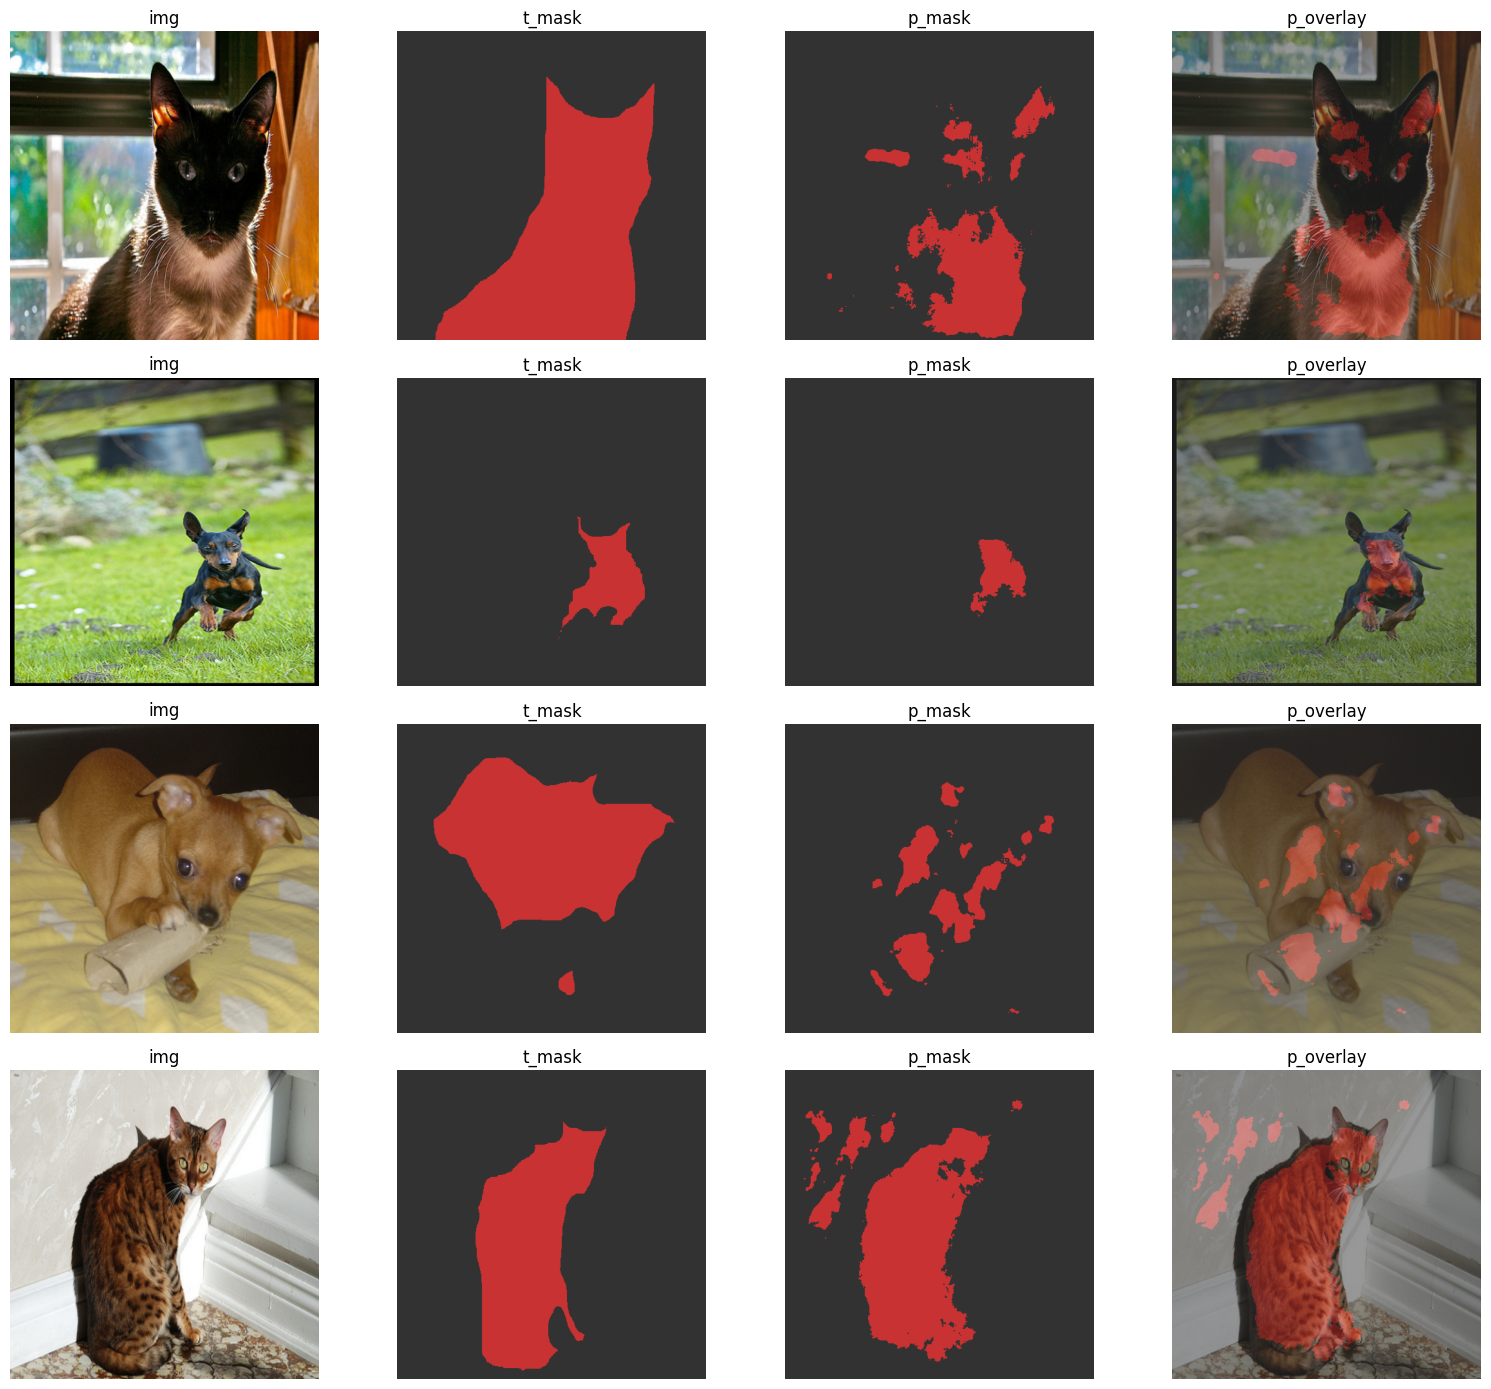

100%|██████████| 370/370 [01:46<00:00,  3.47it/s]


[Epoch2] tr_loss:0.144 | lr:0.005000 | t:106.548


[Eval]: 100%|██████████| 93/93 [00:33<00:00,  2.81it/s]


[Epoch:2] Val Loss: 0.1315, Val mIoU: 90.55%
✅ [Epoch 2] New best model saved! mIoU: 90.55%


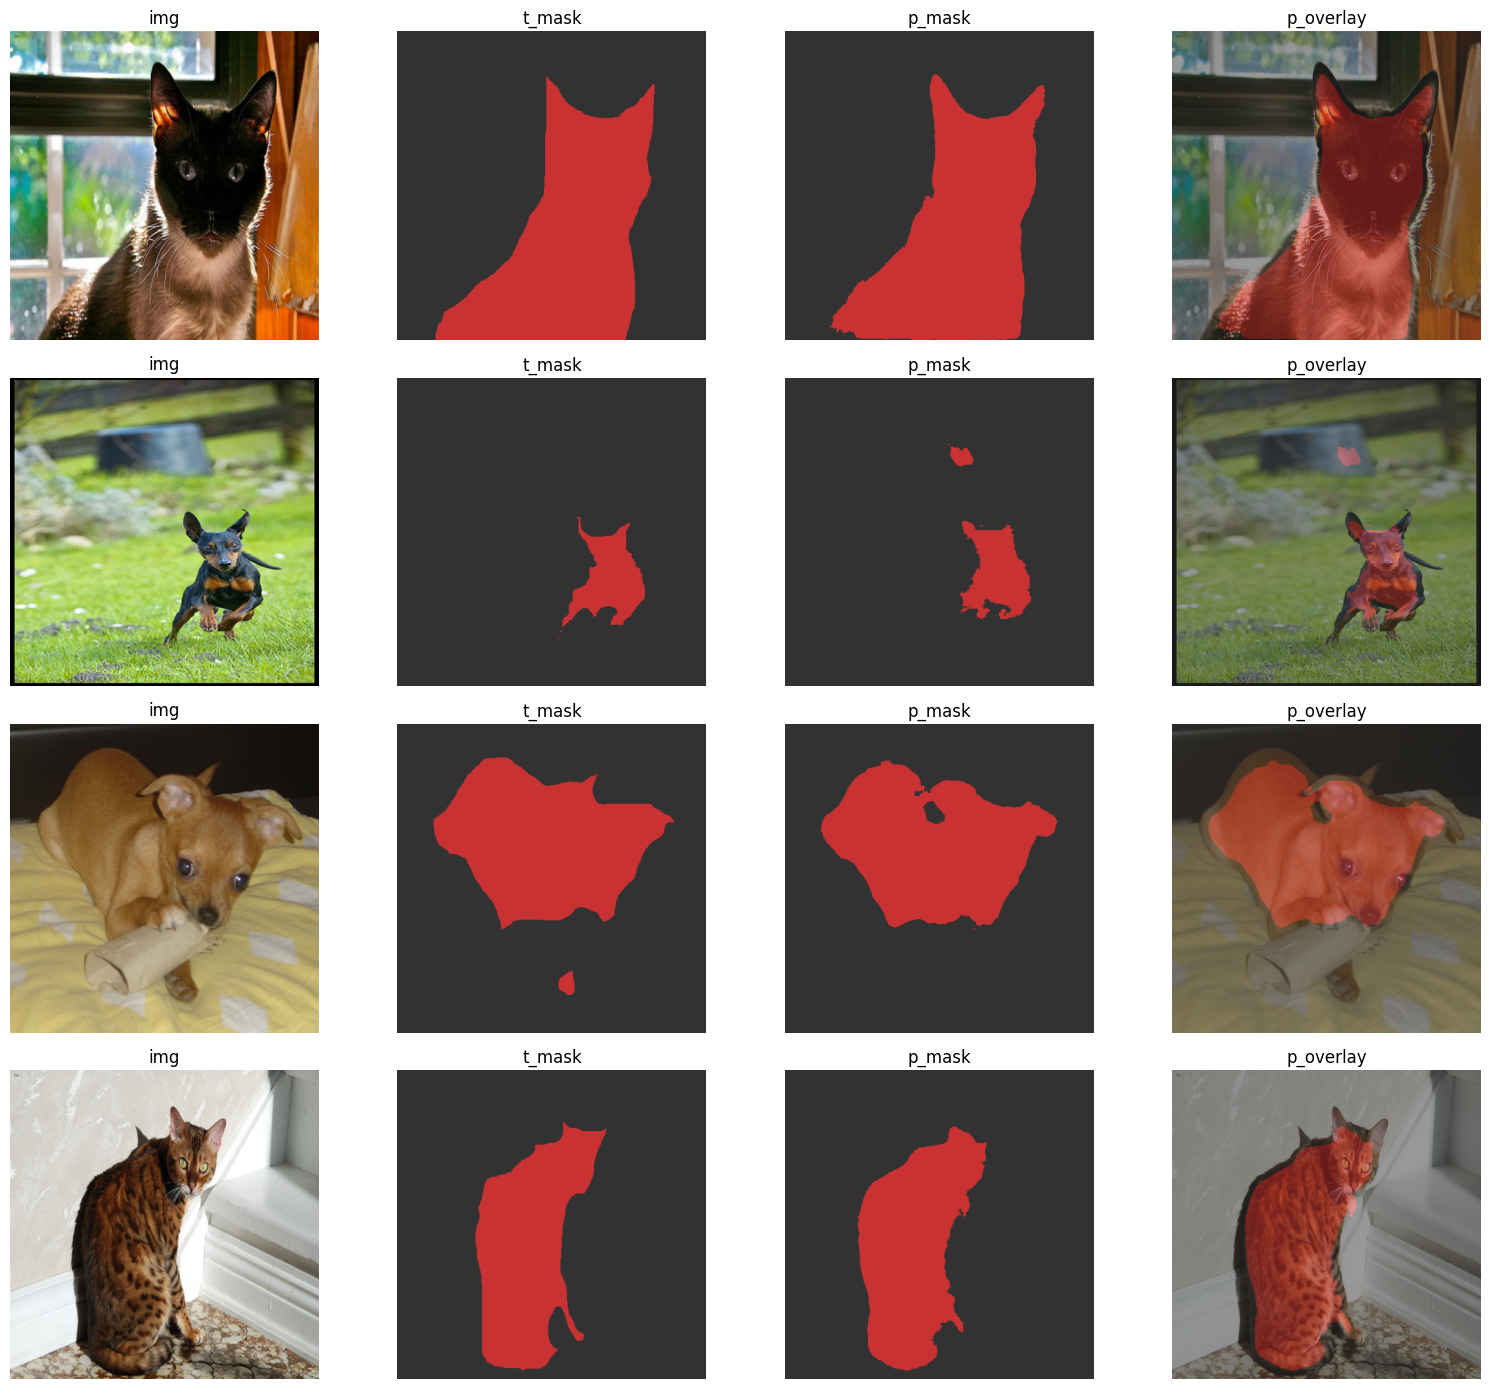

100%|██████████| 370/370 [01:46<00:00,  3.47it/s]


[Epoch3] tr_loss:0.096 | lr:0.005000 | t:106.652


[Eval]: 100%|██████████| 93/93 [00:29<00:00,  3.13it/s]


[Epoch:3] Val Loss: 0.0926, Val mIoU: 91.93%
✅ [Epoch 3] New best model saved! mIoU: 91.93%


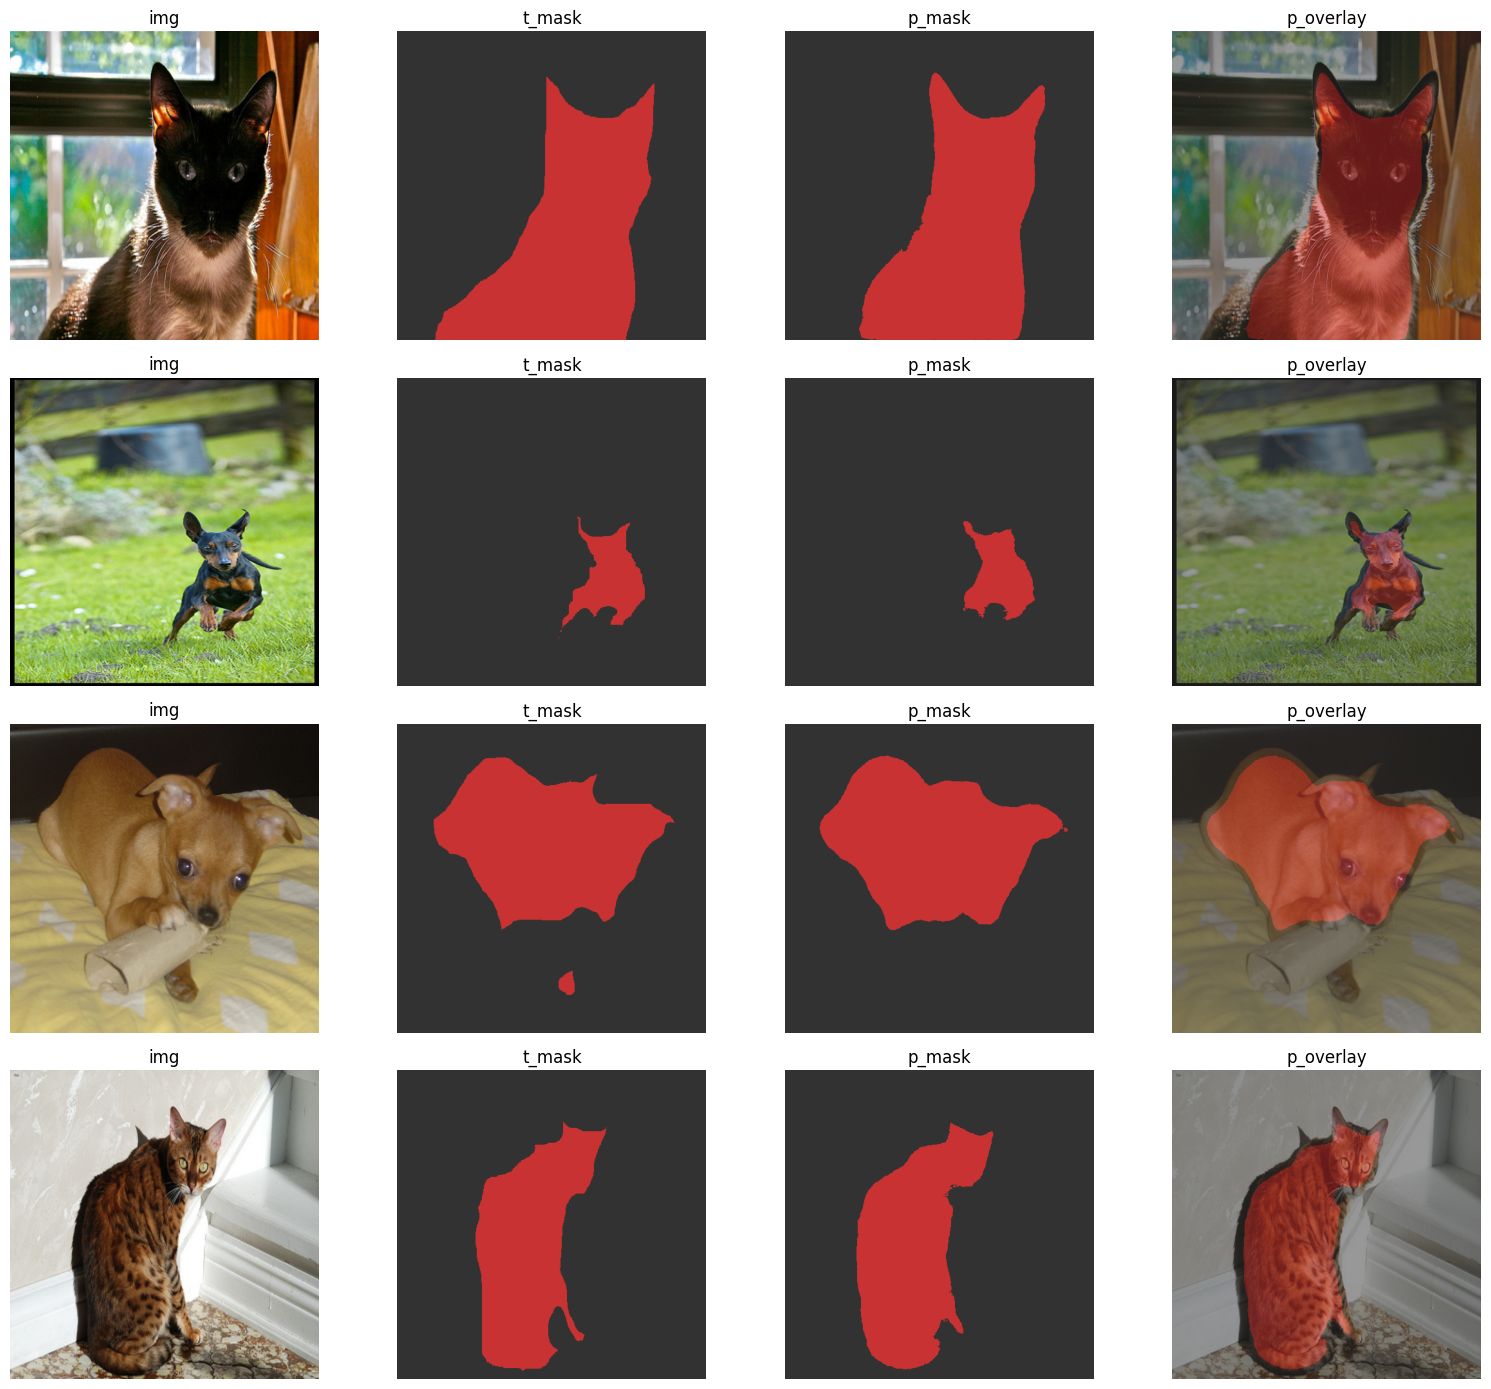

100%|██████████| 370/370 [01:47<00:00,  3.46it/s]


[Epoch4] tr_loss:0.084 | lr:0.005000 | t:107.085


[Eval]: 100%|██████████| 93/93 [00:29<00:00,  3.10it/s]


[Epoch:4] Val Loss: 0.0815, Val mIoU: 92.89%
✅ [Epoch 4] New best model saved! mIoU: 92.89%


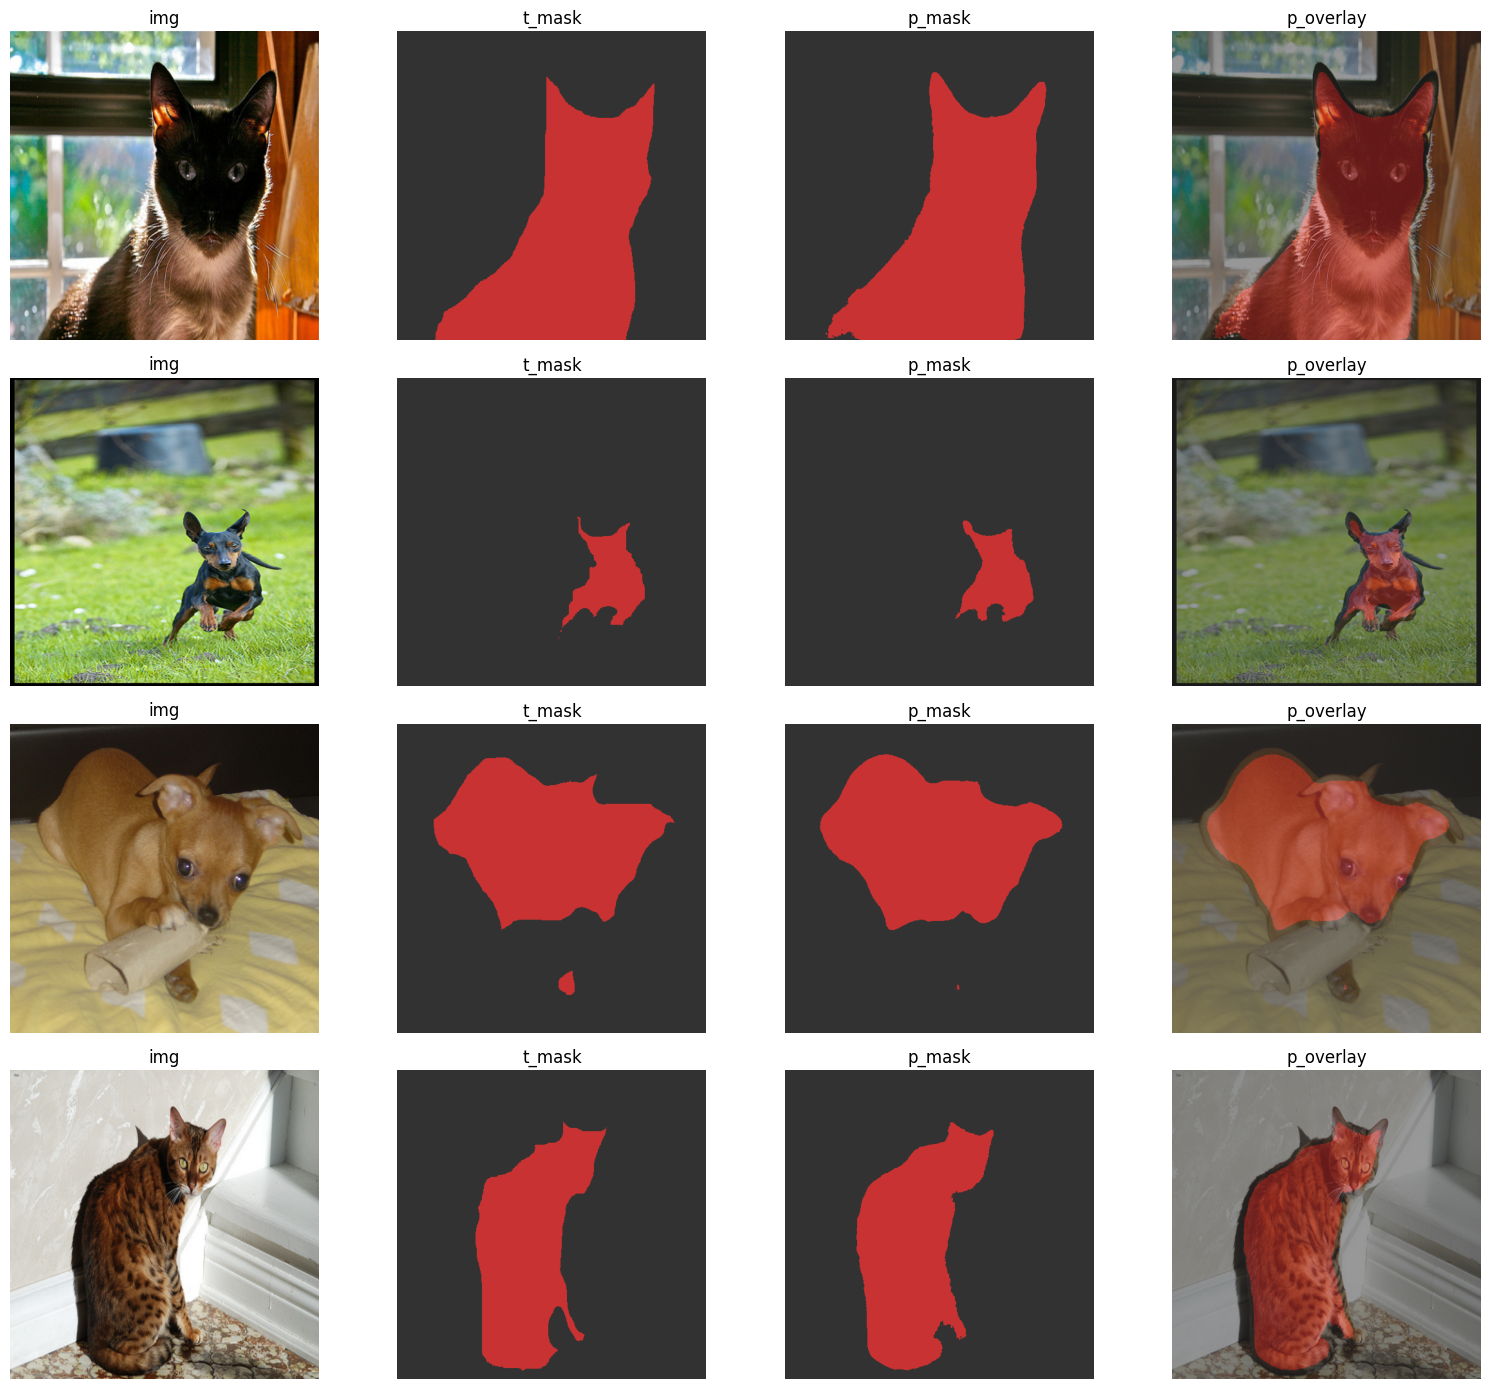

 29%|██▉       | 109/370 [00:32<01:15,  3.48it/s]

In [ ]:
patience = 10
counter = 0
best_val_loss = float('inf')

best_miou = -1.0
for ep in range(1, EPOCHS + 1):
    train(m, criterion, opt, scaler, tr_loader, DEVICE, ep, scheduler)
    val_loss, miou = evaluate(m, val_loader, DEVICE, criterion)

    scheduler.step()
    
    print(f'[Epoch:{ep}] Val Loss: {val_loss:.4f}, Val mIoU: {miou * 100:.2f}%')

    if miou > best_miou:
        best_miou = miou
        torch.save({
            'epoch': ep,
            'model': m.state_dict(),
            'miou': best_miou,
            'config': {
                'IMG_SIZE': IMG_SIZE,
                'N_CLASSES': N_CLASSES,
                "LR": LR,
                "MOMENTUM":MOMENTUM,
                "WEIGHT_DECAY": WEIGHT_DECAY
            }
        }, BEST_PATH)
        print(f'✅ [Epoch {ep}] New best model saved! mIoU: {best_miou*100:.2f}%')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f'⚠️ Early stopping triggered after {patience} epochs of no improvement.')
        break

    show_samples(model=m, loader=val_loader, max_rows=4)

print("--- 학습 최종 종료 ---")